In [12]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
from jax.scipy.linalg import solve_triangular

import gpjax as gpx
import optax as ox
import paramax as px

from non_parametric_pro import ula

from non_parametric_pro.density import ProParameters, pro_logdensity_fn, pro_score_fn
from non_parametric_pro.ula import parametric_ula
from non_parametric_pro.util import posterior_function_draws
from non_parametric_pro.data.synthetic import make_contaminated_data, make_mixture_data
from non_parametric_pro.gp import _full_gp_basis
from non_parametric_pro.adaptation.parameter_adaptation import parameter_adaptation
from scipy import stats
from blackjax.util import run_inference_algorithm

jax.config.update("jax_enable_x64", True)

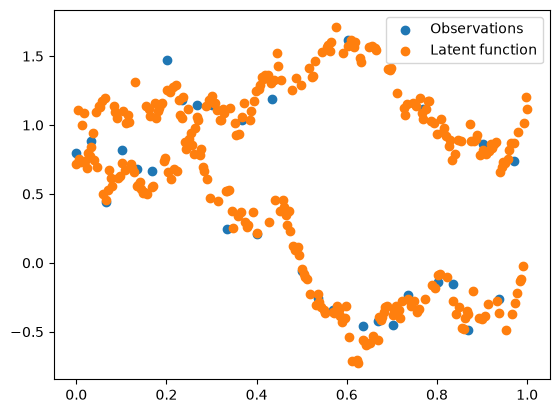

In [3]:
key = jr.PRNGKey(1)

example = make_contaminated_data(key, n_outliers=4)
example = make_mixture_data(key)

fig, ax = plt.subplots()
ax.scatter(example.x_train, example.y_train, label="Observations")
ax.scatter(example.x_test, example.y_truth, label="Latent function")
ax.legend(loc="best")
plt.show()

In [4]:
data = gpx.Dataset(X=example.x_train, y=example.y_train)
kernel = gpx.kernels.Matern12(lengthscale=0.5)
prior = gpx.gps.Prior(mean_function=gpx.mean_functions.Zero(), kernel=kernel)
likelihood = gpx.likelihoods.Gaussian(num_datapoints=data.n)
posterior = prior * likelihood

optim = ox.adam(learning_rate=0.01)

gp_posterior, _ = gpx.fit(
    model=posterior,
    objective=lambda p, d: -gpx.objectives.conjugate_mll(p, d),
    train_data=data,
    optim=optim,
    num_iters=500,
    verbose=False,
)

basis = _full_gp_basis(gp_posterior, data.X, jitter=1e-6)
gp_sigma = gp_posterior.likelihood.obs_stddev
gp_kernel = gp_posterior.prior.kernel

In [ ]:
residuals = (example.y_truth.squeeze() - gp_predictive_mean) / gp_predictive_std

# Q-Q plot against a standard normal
fig, ax = plt.subplots()
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot of standardized residuals vs N(0,1)")
plt.show()

# formal normality tests
print("Shapiro-Wilk:", stats.shapiro(residuals))          # best default choice, small/moderate n
print("D'Agostino-Pearson:", stats.normaltest(residuals)) # good for larger n
print("Kolmogorov-Smirnov:", stats.kstest(residuals, "norm"))  # more conservative, less powerful


In [9]:
example._fields

('x_train', 'y_train', 'x_test', 'y_truth', 'y_obs_test', 'sigma')

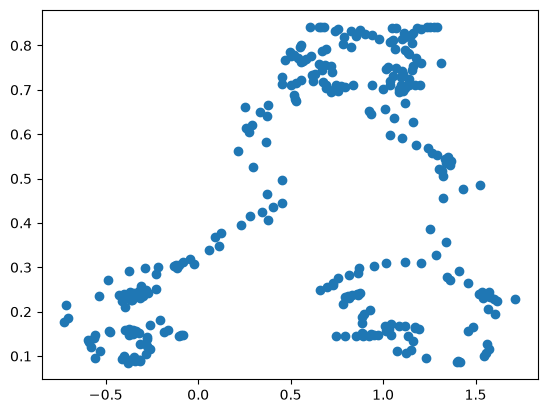

In [15]:
gp_latent_dist = gp_posterior.predict(example.x_test, train_data=data)
gp_predictive_dist = gp_posterior.likelihood(gp_latent_dist)

gp_predictive_mean = gp_predictive_dist.mean
gp_predictive_std = jnp.sqrt(gp_predictive_dist.variance)

plt.scatter(example.y_truth.squeeze(), gp_predictive_mean)

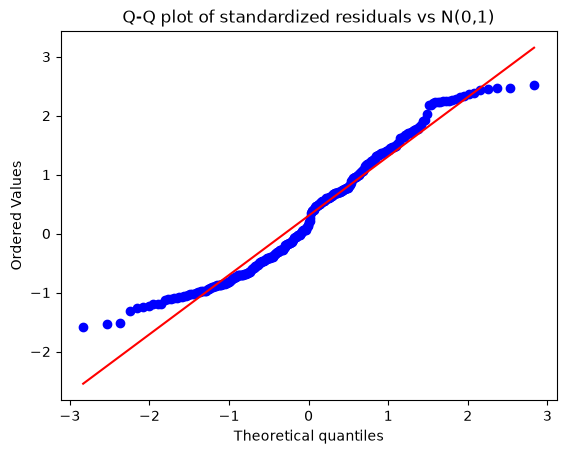

Shapiro-Wilk: 3.2999913274151667e-07


In [17]:
residuals = (example.y_truth.squeeze() - gp_predictive_mean) / gp_predictive_std

# Q-Q plot against a standard normal
fig, ax = plt.subplots()
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title("Q-Q plot of standardized residuals vs N(0,1)")
plt.show()

# formal normality tests
print("Shapiro-Wilk:", stats.shapiro(residuals).pvalue)          # best default choice, small/moderate n

In [18]:
sigma = gpx.parameters.SigmoidBounded(0.25, low=0.05, high=100.0)

params = ProParameters(
    y=data.y,
    basis=basis,
    step_size=1e-3,
    sigma=sigma,
    alpha=1.0,
    tolerance=1e-200,
    jitter=1e-6,
)

J = 10
M = data.n

initial_position = jr.normal(key, (M, J))

adaptation = parameter_adaptation(
    ula,
    pro_logdensity_fn,
    params,
    x_train=example.x_train,
    initial_kernel=gp_kernel,
    warmup_steps=100,
    sigma_adapt_every=10,
    kernel_adapt_every=10,
    objective_fn=pro_score_fn,
    sigma_optimizer=ox.adam(1e-1),
    kernel_optimizer=ox.adam(1e-1),
    progress_bar=True
) 

adaptation_results, adaptation_info = adaptation.run(key, initial_position, num_steps=10000)
pro_kernel = jax.tree.map(lambda x: x[-1], adaptation_info.kernel)
pro_params = adaptation_results.parameters

Running parameter adaptation


<div><progress max="10000" value="10000"></progress> 100.00% [10000/10000 00:00&lt;?]</div>

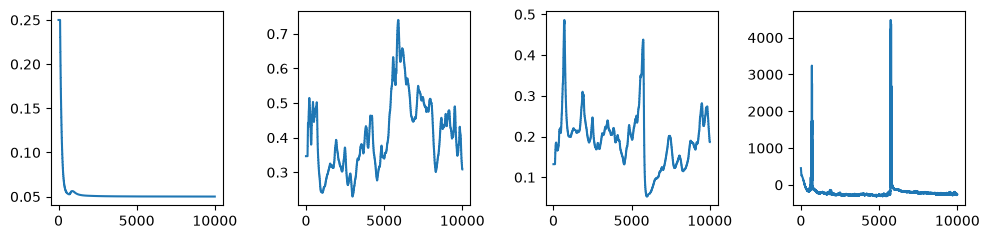

In [19]:
fig, ax = plt.subplots(1, 4, figsize=(10, 2.5))

ax[0].plot(px.unwrap(adaptation_info.sigma))
ax[1].plot(px.unwrap(adaptation_info.kernel.lengthscale))
ax[2].plot(px.unwrap(adaptation_info.kernel.variance))
ax[3].plot(-adaptation_info.sampler_info.score[10:])
plt.tight_layout()
plt.show()

In [20]:
algorithm = parametric_ula(pro_logdensity_fn, pro_params)

out, info = run_inference_algorithm(
    rng_key=key,
    inference_algorithm=algorithm,
    num_steps=10000,
    initial_position=adaptation_results.state.position,
    progress_bar=True
)

<div><progress max="10000" value="10000"></progress> 100.00% [10000/10000 00:00&lt;?]</div>

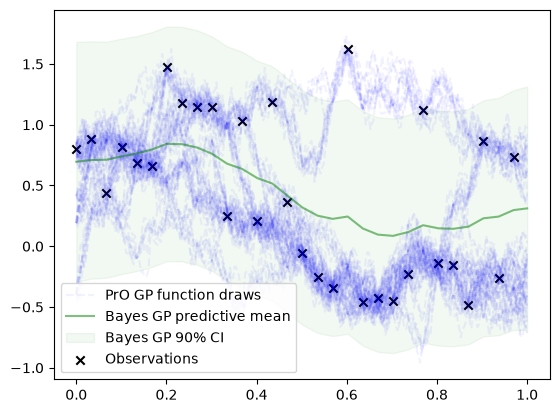

In [21]:
cross_cov = pro_kernel.cross_covariance(example.x_test, example.x_train)
test_basis = solve_triangular(pro_params.basis, cross_cov.T, lower=True).T
test_cov = pro_kernel.gram(example.x_test).as_matrix()

draws = posterior_function_draws(
    key,
    test_basis,
    test_cov,
    out.position,
    num_draws=70,
    jitter=1e-6,
)

x_plot = example.x_test.squeeze()

plt.plot(x_plot, draws[:, 0], color="blue", alpha=0.05, label="PrO GP function draws", linestyle="--")
plt.plot(x_plot, draws[:, 1:], color="blue", alpha=0.05, linestyle="--")
plt.plot(x_plot, gp_predictive_mean, color="green", alpha=0.5, label="Bayes GP predictive mean")
plt.fill_between(x_plot, gp_predictive_mean - 1.64 * gp_predictive_std, gp_predictive_mean + 1.64 * gp_predictive_std, alpha=0.05, color="green", label="Bayes GP 90% CI")
plt.scatter(example.x_train.squeeze(), example.y_train.squeeze(), color="black", label="Observations", marker="x")
plt.legend()
plt.show()